# Parallel workflow


In [226]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [227]:
class BatsmanState(TypedDict , total = False):
    runs    :   int
    balls   :   int
    six     :   int
    four    :   int
    sr      :   float
    bp      :   float
    bpb     :   float
    summary :   str

In [228]:
def sr(state: BatsmanState) -> dict:
    # Strike rate: handling division by zero if balls == 0
    sr_val = (state['runs'] / state['balls']) * 100 if state['balls'] > 0 else 0.0
    return {"sr": sr_val}

In [229]:
def bp(state: BatsmanState) -> dict:
    # Boundary runs percentage: handling division by zero if runs == 0
    bp_val = (((state['four'] * 4) + (state['six'] * 6)) / state['runs']) * 100 if state['runs'] > 0 else 0.0
    return {"bp": bp_val}

In [230]:
def bpb(state: BatsmanState) -> dict:
    # Balls per boundary: handling division by zero if no boundaries hit
    total_boundaries = state['four'] + state['six']
    bpb_val = state['balls'] / total_boundaries if total_boundaries > 0 else float('inf')
    return {"bpb": bpb_val}

In [231]:
def summary(state: BatsmanState) -> dict:
    # Format the final text
    summary_text = f"""
    Runs: {state['runs']},
    Balls: {state['balls']},
    Fours: {state['four']},
    Sixes: {state['six']},
    Strike Rate: {state.get('sr', 0):.2f},
    Boundary Percentage: {state.get('bp', 0):.2f}%
    Balls per Boundary: {state.get('bpb', 0):.2f}
    """
    return {"summary": summary_text.strip()}

In [232]:
graph = StateGraph(BatsmanState)

# Add nodes 
graph.add_node("SR", sr)
graph.add_node("BP", bp)
graph.add_node("BPB", bpb)
graph.add_node("Summary", summary)

# Add edges (Fan-out from START)
graph.add_edge(START, "SR")
graph.add_edge(START, "BP")
graph.add_edge(START, "BPB")

# Add edges (Fan-in to Summary)
graph.add_edge("SR", "Summary")
graph.add_edge("BP", "Summary")
graph.add_edge("BPB", "Summary")

# End workflow
graph.add_edge("Summary", END)

# Compile 
workflow_pg = graph.compile()

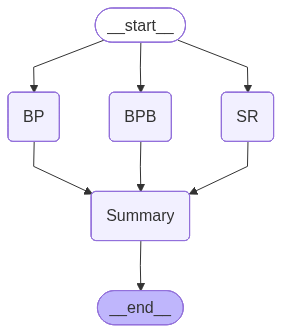

In [233]:
workflow_pg

In [234]:
if __name__ == "__main__":
    input_state = {
        "runs": 120,
        "balls": 80,
        "four": 10,
        "six": 5
    }

    final_state = workflow_pg.invoke(input_state)

    print("----- Final Summary Generated By LangGraph -----")
    print(final_state['summary'])

----- Final Summary Generated By LangGraph -----
Runs: 120,
    Balls: 80,
    Fours: 10,
    Sixes: 5,
    Strike Rate: 150.00,
    Boundary Percentage: 58.33%
    Balls per Boundary: 5.33


# Example 2

### Model Setup

In [235]:
import os 
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpoint , ChatHuggingFace
#load environment 
load_dotenv()
#check token 
token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
if not token:
    print("Error: HUGGINGFACEHUB_API_TOKEN is not set in the .env file.")
else:
    print("Done")
#  Setup the Endpoint
repo_id = "meta-llama/Llama-3.1-8B-Instruct"

llm_H = HuggingFaceEndpoint(
    repo_id=repo_id,
    task="text-generation",
    max_new_tokens=512,
    temperature=0.7,
    huggingfacehub_api_token=token,
)

Done


In [236]:
#  Wrap it in ChatHuggingFace (This handles the "conversational" format for you)
model = ChatHuggingFace(llm=llm_H)

### Structure Schema

In [237]:
import operator
from typing import TypedDict, Annotated, List
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate

In [238]:
class EvaluationScore(BaseModel):
    feedback : str = Field(description="Feedback on the generated Eassy ")
    score : int = Field(description="Score out of 10",ge=0, le=10)

In [239]:
parser = PydanticOutputParser(pydantic_object=EvaluationScore)

In [240]:
# 3. Apna Prompt define karein (ismein format_instructions add karna zaroori hai)
prompt = PromptTemplate(
    template="You are an expert essay evaluator.\n{format_instructions}\n\nEvaluate the following essay:\n{essay}",
    input_variables=["essay"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)

# 4. Chain banayein (Prompt -> Model -> Parser)
# Yahan 'model' aapka ChatHuggingFace instance hai
model_with_structure_output = prompt | model | parser

In [241]:
# 1. Wahi sample essay define karein
sample_essay = """Pakistan’s Role During the Israel–Iran War
Introduction

The conflict between Iran and Israel has created serious tensions in the Middle East and has affected global politics. Many countries have taken different positions in this conflict. Pakistan, being an important Muslim country and a neighbor of Iran, has played a careful and diplomatic role. Instead of directly participating in the war, Pakistan tried to reduce tensions and promote peace through diplomacy.

Pakistan’s Neutral and Balanced Policy

Pakistan officially adopted a policy of neutrality during the Iran–Israel conflict. The government stated that Pakistan would not become part of any military alliance or war between other countries. Pakistan also declared that it would not allow its territory, airspace, or naval bases to be used for attacks against Iran. This policy helped Pakistan avoid direct involvement in the conflict while maintaining relations with different countries.

Diplomatic Efforts for Peace

Pakistan played an important diplomatic role in trying to reduce tensions between Iran and its opponents. The government held meetings with several countries and encouraged dialogue instead of war. Pakistan even hosted discussions involving regional and international leaders to find a peaceful solution to the conflict. These diplomatic efforts showed Pakistan’s commitment to stability in the region.

Mediation and Ceasefire Efforts

Pakistan also attempted to act as a mediator between the opposing sides. Pakistani leadership worked with international partners to help negotiate a temporary ceasefire and prevent the conflict from expanding further. These efforts were considered an important diplomatic achievement and helped reduce immediate tensions in the region.

Support for International Law and Palestine

Pakistan has consistently criticized Israeli military actions and expressed political and moral support for Iran and the Palestinian cause. Pakistani leaders emphasized that lasting peace in the Middle East requires justice for Palestinians and respect for international law. Pakistan has often raised these issues in international forums such as the United Nations.

Challenges Faced by Pakistan

Despite its efforts, Pakistan faced many challenges during the conflict. The country shares a long border with Iran and also has strong relations with Gulf states and Western countries. Because of these connections, Pakistan had to carefully balance its foreign policy to avoid damaging its relationships while still supporting regional peace.

Conclusion

In conclusion, Pakistan’s role in the Iran–Israel war was mainly diplomatic and strategic rather than military. The country tried to maintain neutrality, encouraged peace talks, and worked to prevent further escalation of the conflict. Pakistan’s actions demonstrated its intention to promote stability and peaceful solutions in a highly sensitive international crisis.
"""

print("Evaluating essay, please wait...\n")

# 2. Chain ko invoke karein
try:
    # Aapke code mein chain ka naam 'model_with_structure_output' tha
    result = model_with_structure_output.invoke({"essay": sample_essay.strip()})
    
    # 3. Output check karein
    print("--- Evaluation Result ---")
    print(f"Score: {result.score} / 10")
    print(f"Feedback: {result.feedback}")
    
    print("\n--- Raw Pydantic Object ---")
    print(repr(result))

except Exception as e:
    print(f"Parsing error (model might not have returned strict JSON): {e}")

Evaluating essay, please wait...

--- Evaluation Result ---
Score: 8 / 10
Feedback: The essay provides a clear and well-structured overview of Pakistan's role in the Iran-Israel war. The writer effectively uses diplomatic and strategic language to analyze Pakistan's actions and intentions. However, the essay could benefit from more in-depth analysis of the challenges faced by Pakistan and potential implications for the region. Additionally, some sentences could be tightened up for better clarity and concision.

--- Raw Pydantic Object ---
EvaluationScore(feedback="The essay provides a clear and well-structured overview of Pakistan's role in the Iran-Israel war. The writer effectively uses diplomatic and strategic language to analyze Pakistan's actions and intentions. However, the essay could benefit from more in-depth analysis of the challenges faced by Pakistan and potential implications for the region. Additionally, some sentences could be tightened up for better clarity and concisio

### Schema for Graph

In [242]:
class UPSCstate(TypedDict):
    eassy: str 
    language_feedback : str 
    analysis_feedback : str  
    clarity_of_thoughts_feedback : str 
    overall_feedback : str
    individual_scores : Annotated[List[int], operator.add]
    avg_score : float
    


In [243]:
def evaluate_language(state: UPSCstate):
    prompt_1=f"Evaluate the language used in the following essay and provide feedback:\n\n{state['eassy']}"
    output = model_with_structure_output.invoke(prompt_1)
    return {"language_feedback": output.feedback, "individual_scores": [output.score]}


In [244]:
def evaluate_analysis(state: UPSCstate):
    prompt_1=f"Evaluate the depth of analysis  in the following essay and provide feedback:\n\n{state['eassy']}"
    output = model_with_structure_output.invoke(prompt_1)
    return {"analysis_feedback": output.feedback, "individual_scores": [output.score]}


In [245]:
def final_evaluation(state: UPSCstate):

    # 1. FIXED Key Name in prompt
    prompt = f'''Based on the following feedbacks create a summarized feedback:
    Language feedback: {state.get("language_feedback", "N/A")} 
    Depth of analysis feedback: {state.get("analysis_feedback", "N/A")} 
    Clarity of thought feedback: {state.get("clarity_of_thoughts_feedback", "N/A")}'''
    
    # 2. Generate overall feedback
    overall_feedback = model.invoke(prompt).content

    # 3. Average Calculation with safety check
    scores = state.get('individual_scores', [])
    if scores and len(scores) > 0:
        avg_score = sum(scores) / len(scores)
    else:
        avg_score = 0.0

    return {
        'overall_feedback': overall_feedback, 
        'avg_score': round(avg_score, 2) # Round off for clean output
    }

In [246]:
def evaluate_thoughts(state: UPSCstate):
    prompt_1 = f"Evaluate the clarity of thoughts in the following essay and provide feedback:\n\n{state['eassy']}"
    output = model_with_structure_output.invoke(prompt_1)
    
    # Spelling 'clearity' se 'clarity' kar di gayi hai taake UPSCstate se match kare
    return {"clarity_of_thoughts_feedback": output.feedback, "individual_scores": [output.score]}

In [247]:

# 3. BUILD GRAPH
graph = StateGraph(UPSCstate)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thoughts)
graph.add_node('final_evaluation', final_evaluation)

# Fan-out: Start se teeno ko parallel run karo
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

# 4. FIXED: Fan-in: Teeno ka wait karo, phir ek sath final_evaluation chalao
graph.add_edge(
    ['evaluate_language', 'evaluate_analysis', 'evaluate_thought'], 
    'final_evaluation'
)

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

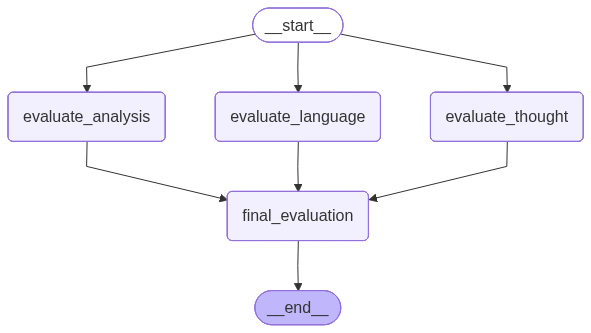

In [248]:
workflow

In [249]:
essay2 = """India and AI Time

Now world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.

India have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.

In farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.

But problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.

One more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

India must all people together – govern, school, company and normal people. We teach AI and make sure AI not bad. Also talk to other country and learn from them.

If India use AI good way, we become strong, help poor and make better life. But if only rich use AI, and poor no get, then big bad thing happen.

So, in short, AI time in India have many hope and many danger. We must go right road. AI must help all people, not only some. Then India grow big and world say "good job India"."""

In [250]:
initial_state = {
    "eassy": essay2
}

In [251]:
workflow_result = workflow.invoke(initial_state)

In [252]:
print("----- Final Summary Generated By LangGraph -----")
print(workflow_result.keys())

----- Final Summary Generated By LangGraph -----
dict_keys(['eassy', 'language_feedback', 'analysis_feedback', 'clarity_of_thoughts_feedback', 'overall_feedback', 'individual_scores', 'avg_score'])


In [253]:
#loop to print all keys 
for key, value in workflow_result.items():
    print("Key :", key)
    print(f"{key}: {value}\n")
    print("-----------------------------\n")

Key : eassy
eassy: India and AI Time

Now world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.

India have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.

In farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.

But problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.

One more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

Indi